Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


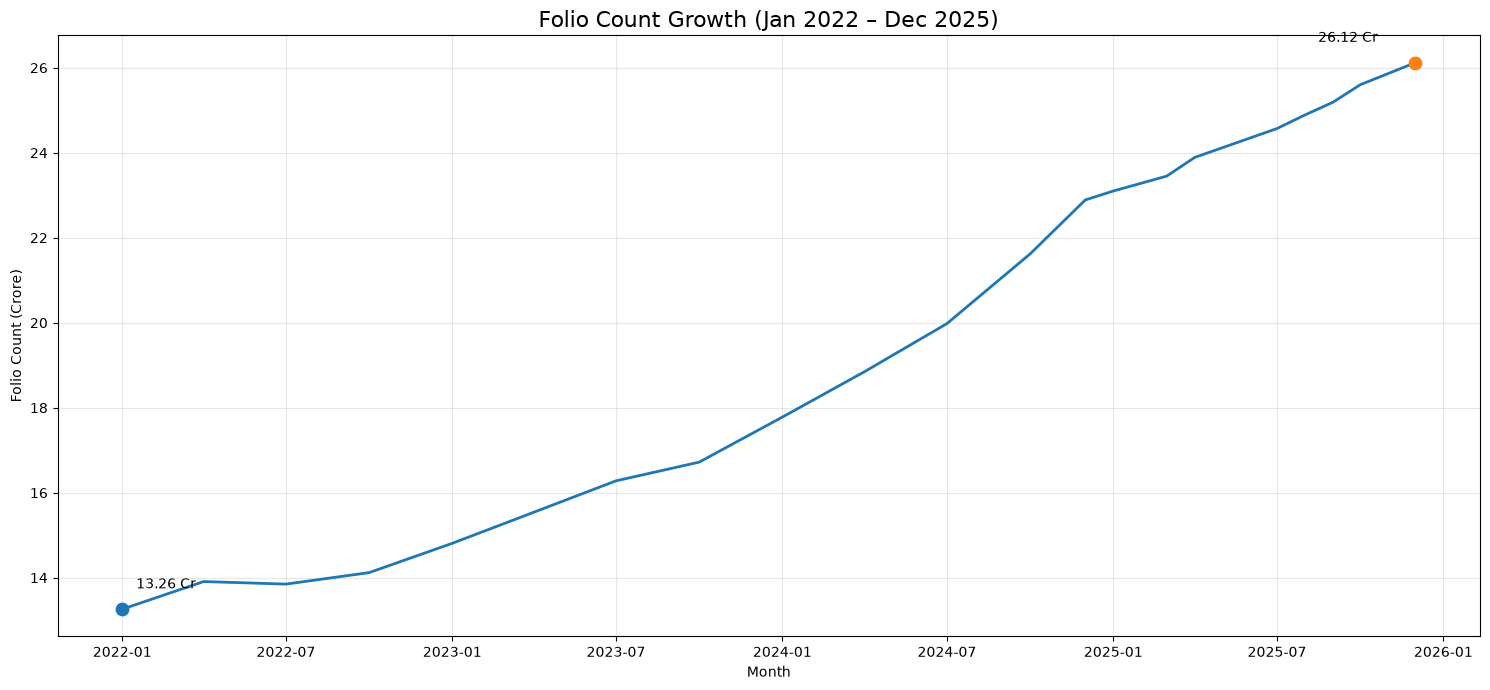

Task 7 completed successfully.
Chart saved to: Reports/Folio_Count_Growth.png


In [1]:

# DAY 3 - TASK 7: FOLIO COUNT GROWTH

import pandas as pd
import matplotlib.pyplot as plt

# Loading folio count data:
df = pd.read_csv("../Data/Raw/06_industry_folio_count.csv")

# Cleaning column names:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:", df.columns.tolist())
display(df.head())

# Identifying the date/month column:
date_col = next(
    col for col in df.columns
    if "month" in col or "date" in col
)

# Identifying folio count column:
folio_col = next(
    col for col in df.columns
    if "folio" in col
)

# Convert date to datetime:
df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce"
)

# Convert folio count to numeric:
df[folio_col] = pd.to_numeric(
    df[folio_col],
    errors="coerce"
)

# Removing invalid rows:
df = df.dropna(
    subset=[date_col, folio_col]
)

# Sort chronologically:
df = df.sort_values(date_col)

# Keep Jan 2022 - Dec 2025:
df = df[
    (df[date_col] >= "2022-01-01") &
    (df[date_col] <= "2025-12-31")
]

# CREATE LINE CHART

plt.figure(figsize=(15, 7))

plt.plot(
    df[date_col],
    df[folio_col],
    linewidth=2
)

# Mark starting point:
if not df.empty:
    start = df.iloc[0]

    plt.scatter(
        start[date_col],
        start[folio_col],
        s=80,
        zorder=5
    )

    plt.annotate(
        f"{start[folio_col]:.2f} Cr",
        xy=(start[date_col], start[folio_col]),
        xytext=(10, 15),
        textcoords="offset points"
    )

# Mark ending point:
if not df.empty:
    end = df.iloc[-1]

    plt.scatter(
        end[date_col],
        end[folio_col],
        s=80,
        zorder=5
    )

    plt.annotate(
        f"{end[folio_col]:.2f} Cr",
        xy=(end[date_col], end[folio_col]),
        xytext=(-70, 15),
        textcoords="offset points"
    )

plt.title(
    "Folio Count Growth (Jan 2022 – Dec 2025)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Folio Count (Crore)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart:
plt.savefig(
    "../Reports/Folio_Count_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Task 7 completed successfully.")
print("Chart saved to: Reports/Folio_Count_Growth.png")